# Bernstein-Vazirani Algorithm — Demo

Walks through `algorithms.bernstein_vazirani` end to end: build the oracle
for a hidden bitstring, visualize the circuit and its measurement
histogram, and recover the hidden string via `find_hidden_string()`.

See [../math.md](../math.md) for the theory and [../paper.md](../paper.md)
for the circuit derivation — note it's the *same circuit* as
[../../deutsch_jozsa/](../../deutsch_jozsa/), just a different oracle.

In [1]:
# Make the repo importable regardless of the working directory this
# notebook is executed from (e.g. `jupyter execute` defaults to the
# notebook's own directory, not the repo root).
import sys
from pathlib import Path

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

In [2]:
from algorithms.bernstein_vazirani import visualization
from algorithms.bernstein_vazirani.circuit import build_oracle_query_circuit
from algorithms.bernstein_vazirani.execution import AerExecutor
from algorithms.bernstein_vazirani.implementation import find_hidden_string
from algorithms.bernstein_vazirani.oracles import HiddenStringOracle

s = "101"
oracle = HiddenStringOracle(s)
executor = AerExecutor()
print(f"Hidden string: {s}")

Hidden string: 101


## The circuit

`H^n -> oracle -> H^n -> measure` — the oracle here is `O(len(s))` CNOTs,
one per set bit of `s`.

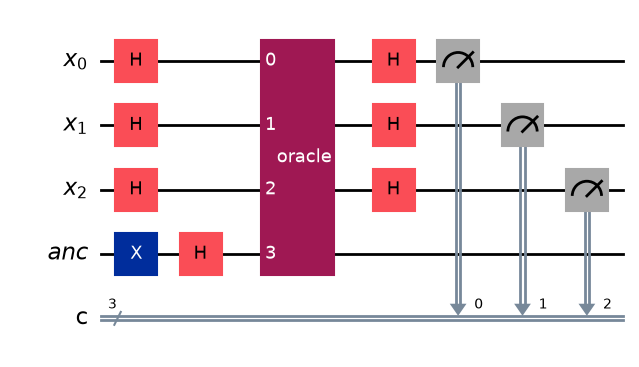

In [3]:
circuit = build_oracle_query_circuit(len(s), oracle)
visualization.circuit_figure(circuit)

## Running it

Unlike Deutsch-Jozsa's "all-zeros or not" result, here the measured
bitstring *is* the hidden string `s` itself, with certainty.

{'101': 100}


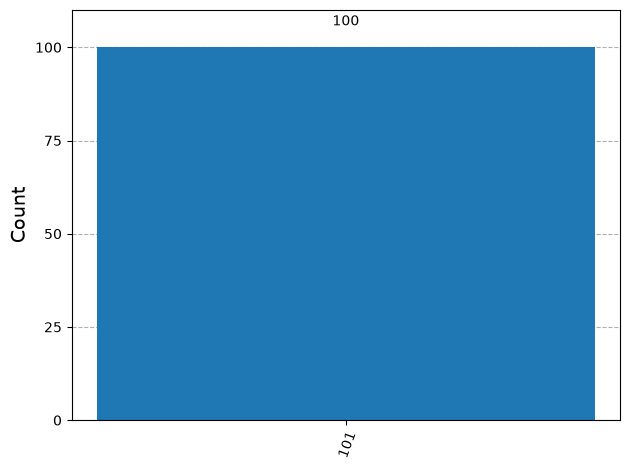

In [4]:
counts = executor.run(circuit, shots=100)
print(counts)
visualization.plot_measurement_histogram(counts)

## `find_hidden_string`

Wraps circuit construction, execution, and interpretation into one call —
a single shot suffices (see math.md).

In [5]:
for test_s in ["101", "000", "111", "1100"]:
    result = find_hidden_string(len(test_s), HiddenStringOracle(test_s))
    print(f"s={test_s!r} -> recovered {result!r} ({'OK' if result == test_s else 'MISMATCH'})")

s='101' -> recovered '101' (OK)
s='000' -> recovered '000' (OK)
s='111' -> recovered '111' (OK)


s='1100' -> recovered '1100' (OK)
